In [1]:
import dgl
import dgl.function as fn
import torch as th
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, average_precision_score
from dgl import DGLGraph
import random
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, roc_auc_score

gcn_msg = fn.copy_src(src='h', out='m')
gcn_reduce = fn.sum(msg='m', out='h')

Using backend: pytorch


In [2]:
class GCNLayer(nn.Module):
    def __init__(self, in_feats, out_feats):
        super(GCNLayer, self).__init__()
        self.linear = nn.Linear(in_feats, out_feats)
        # in @ W = out w shape = (in_sz, out_sz)
        # out_sz = (16 x alpha)
        # in_sz = (3703 x alpha)
        # alpha = 3327
        
    def forward(self, g, feature):
        if feature.shape[1] == 3703:
            print("first fwd")
        else:
            print("second fwd")
        with g.local_scope():
            g.ndata['h'] = feature
            g.update_all(gcn_msg, gcn_reduce)
            h = g.ndata['h']
            return self.linear(h)

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.layer1 = GCNLayer(3703, 16)
        self.layer2 = GCNLayer(16, 6)
        self.embed = None
        
    def forward(self, g, features):
        x = self.layer1(g, features)
        print("relu time")
        x = F.relu(x)
        x = self.layer2(g, x)
        return x

    
# reproducibility
def set_seed(seed):
    th.backends.cudnn.deterministic = True
    th.backends.cudnn.benchmark = False
    th.manual_seed(seed)
    th.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

from dgl.data import citation_graph as citegrh
import networkx as nx

def load_citeseer_data():
    data = citegrh.load_citeseer()
    features = th.FloatTensor(data.features)
    labels = th.LongTensor(data.labels)
    train_mask = th.BoolTensor(data.train_mask)
    test_mask = th.BoolTensor(data.test_mask)
    g = DGLGraph(data.graph)
    return g, features, labels, train_mask, test_mask

def evaluate(model, g, features, labels, mask):
    model.eval()
    with th.no_grad():
        logits = model(g, features)
        logits = logits[mask]
        labels = labels[mask]
        _, indices = th.max(logits, dim=1)
        correct = th.sum(indices == labels)
        return correct.item() * 1.0 / len(labels)

import time
import numpy as np
g, features, labels, train_mask, test_mask = load_citeseer_data()

Finished data loading and preprocessing.
  NumNodes: 3327
  NumEdges: 9228
  NumFeats: 3703
  NumClasses: 6
  NumTrainingSamples: 120
  NumValidationSamples: 500
  NumTestSamples: 1000


/home/matalan/.local/lib/python3.8/site-packages/dgl/data/citation_graph.py:140: RuntimeWarning: divide by zero encountered in power
  r_inv = np.power(rowsum, -1).flatten()


In [3]:
activation = {}
def get_activation(name):
    def hook(model, input, output):
        print("using hook")
        activation[name] = output.detach()
    return hook

net1 = Net()
net1.layer1.register_forward_hook(get_activation('layer1'))

In [4]:
g.add_edges(g.nodes(), g.nodes())
optimizer1 = th.optim.Adam(net1.parameters(), lr=1e-2)
dur =[]

set_seed(42)
for epoch in range(100):
    if epoch >=3:
        t0 = time.time()
        
        net1.train()
        logits = net1(g, features)
        logp = F.log_softmax(logits, 1)
        loss = F.nll_loss(logp[train_mask], labels[train_mask])
        
        optimizer1.zero_grad()
        loss.backward()
        optimizer1.step()
        
        if epoch >=3:
            dur.append(time.time() - t0)
            
        acc= evaluate(net1, g, features, labels, test_mask) 
        
        print("Epoch {:05d} | loss {:.4f} | Test Acc {:.4f} | Time(s) {:.4f}".format(
        epoch, loss.item(), acc, np.mean(dur)))
        

print(activation['layer1'])
activation['layer1'].shape


first fwd
using hook
relu time
second fwd
first fwd
using hook
relu time
second fwd
Epoch 00003 | loss 1.7941 | Test Acc 0.2520 | Time(s) 0.1818
first fwd
using hook
relu time
second fwd
first fwd
using hook
relu time
second fwd
Epoch 00004 | loss 1.7015 | Test Acc 0.2800 | Time(s) 0.1496
first fwd
using hook
relu time
second fwd
first fwd
using hook
relu time
second fwd
Epoch 00005 | loss 1.6037 | Test Acc 0.2900 | Time(s) 0.1384
first fwd
using hook
relu time
second fwd
first fwd
using hook
relu time
second fwd
Epoch 00006 | loss 1.5107 | Test Acc 0.3020 | Time(s) 0.1327
first fwd
using hook
relu time
second fwd
first fwd
using hook
relu time
second fwd
Epoch 00007 | loss 1.4288 | Test Acc 0.2920 | Time(s) 0.1300
first fwd
using hook
relu time
second fwd
first fwd
using hook
relu time
second fwd
Epoch 00008 | loss 1.3522 | Test Acc 0.3130 | Time(s) 0.1294
first fwd
using hook
relu time
second fwd
first fwd
using hook
relu time
second fwd
Epoch 00009 | loss 1.2779 | Test Acc 0.3440 | 

using hook
relu time
second fwd
first fwd
using hook
relu time
second fwd
Epoch 00060 | loss 0.0117 | Test Acc 0.6110 | Time(s) 0.1181
first fwd
using hook
relu time
second fwd
first fwd
using hook
relu time
second fwd
Epoch 00061 | loss 0.0111 | Test Acc 0.6090 | Time(s) 0.1181
first fwd
using hook
relu time
second fwd
first fwd
using hook
relu time
second fwd
Epoch 00062 | loss 0.0106 | Test Acc 0.6090 | Time(s) 0.1180
first fwd
using hook
relu time
second fwd
first fwd
using hook
relu time
second fwd
Epoch 00063 | loss 0.0101 | Test Acc 0.6090 | Time(s) 0.1179
first fwd
using hook
relu time
second fwd
first fwd
using hook
relu time
second fwd
Epoch 00064 | loss 0.0097 | Test Acc 0.6090 | Time(s) 0.1183
first fwd
using hook
relu time
second fwd
first fwd
using hook
relu time
second fwd
Epoch 00065 | loss 0.0092 | Test Acc 0.6090 | Time(s) 0.1182
first fwd
using hook
relu time
second fwd
first fwd
using hook
relu time
second fwd
Epoch 00066 | loss 0.0089 | Test Acc 0.6090 | Time(s) 0.

torch.Size([3327, 16])

In [5]:
print(labels)

tensor([3, 1, 5,  ..., 3, 1, 5])


In [6]:
weight = None
for name, parameters in net1.named_parameters():
    if "layer1" in name:
        weight = parameters.data
        print(weight.shape)
        print(parameters.data)
        break
        
embedding = nn.Embedding.from_pretrained(weight)
# Get embeddings for index 1
#input = torch.LongTensor([1])embedding(input)
#net1.__dict__
#net1.get_submodule("layer2.linear")

torch.Size([16, 3703])
tensor([[-0.0880, -0.1274,  0.0482,  ...,  0.1305, -0.0097,  0.3457],
        [ 0.2091, -0.0559, -0.1829,  ..., -0.2647,  0.0101, -0.3099],
        [ 0.2636, -0.0632, -0.1547,  ...,  0.0730,  0.0142, -0.2783],
        ...,
        [ 0.1555,  0.2089,  0.1263,  ...,  0.1180, -0.0084, -0.2910],
        [-0.0935,  0.0809,  0.1591,  ...,  0.2259,  0.0066,  0.3611],
        [ 0.2368, -0.1392, -0.0439,  ...,  0.2300, -0.0083,  0.4229]])


In [7]:
list(net1.children())

[GCNLayer(
   (linear): Linear(in_features=3703, out_features=16, bias=True)
 ),
 GCNLayer(
   (linear): Linear(in_features=16, out_features=6, bias=True)
 )]

In [8]:
print("in shape: ", features.shape)
print("in data head: ", features.data[0:3][0:5])
first_layer_out = list(net1.children())[0](g, features) # layer1.forward(g, features)
print("[0] shape: ", first_layer_out.shape)
print("[0] data head: ", first_layer_out.data[0:3][0:5])
tmp_non_linear = F.relu(first_layer_out)
print("After relu: ", tmp_non_linear)
second_layer_out = list(net1.children())[1](g, tmp_non_linear)
print("[1] shape: ", second_layer_out.shape)
print("[1] data head: ", second_layer_out.data[0:3][0:5])

in shape:  torch.Size([3327, 3703])
in data head:  tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])
first fwd
using hook
[0] shape:  torch.Size([3327, 16])
[0] data head:  tensor([[ 3.3957e-01,  7.2555e-01,  7.4087e-01, -8.4981e-05,  8.2988e-01,
          1.9192e-02,  5.3972e-01, -2.4052e-04,  3.0755e-02,  8.2298e-01,
         -2.1720e-04,  6.7995e-01, -1.6324e-01,  2.3255e-01, -9.9913e-03,
          6.9802e-01],
        [ 1.1757e+00,  2.6395e-01,  1.6558e-01,  6.8172e-01,  9.3728e-01,
          4.9103e-01,  7.1419e-01,  8.2822e-01,  3.8663e-01,  9.6965e-01,
          1.2174e+00,  1.1226e+00, -3.0824e-01,  5.1276e-01,  1.1204e+00,
          2.7412e-01],
        [-1.5854e-03,  7.9441e-01,  8.4923e-01,  6.0285e-05, -2.6716e-04,
          1.8887e-01, -7.4903e-03, -1.1615e-05,  9.8541e-01, -4.6474e-04,
         -3.8632e-04, -8.2002e-05, -1.6466e-01,  1.0085e+00, -9.6523e-03,
          5.9144e-02]])
After relu:  tensor(

In [9]:
#import copy
#class_num = np.random.randint(6)
#binary_class = np.zeros((second_layer_out.shape[0],), dtype="int32")
#for article in range(second_layer_out.shape[0]):
#    if np.argmax(second_layer_out[article].data).data == class_num:
#        binary_class[article] =  1
#    else:
#        binary_class[article] =  0
#print(binary_class.shape)
#print(binary_class[0:3][0:10])

#nw_classifier.fit(features, binary_class)

In [10]:
X = first_layer_out.data
y = labels

In [11]:
print(g)

DGLGraph(num_nodes=3327, num_edges=12555,
         ndata_schemes={}
         edata_schemes={})


In [12]:
net1.parameters()

<generator object Module.parameters at 0x7f2d57429120>

### NUQ method implementation

In [13]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

from nw_uncertainty import NewNW

In [14]:
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams.update({'font.size': 19})


def plot_data(X, y):
    plt.close()
    plt.figure()
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.tight_layout()
    plt.show()


def make_data(total_size=5000, centers=np.array([[-4., -4.], [0., 4.]])):
    X, y = make_blobs(n_samples=total_size, n_features=2, centers=centers)
    return X, y

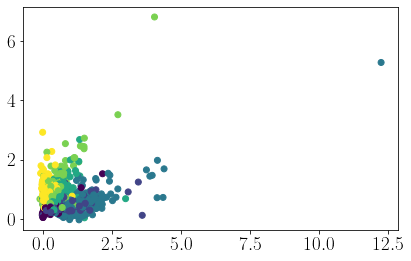

ROC AUC : [('test', 0.6810368015451723)]
ISJ, [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]: 
  {'epistemic': array([5.6524199]), 'aleatoric': array([-3.40243574]), 'total': array([5.65253671])}, 
 [10.0, 0.0, 10.0, 0.0, 10.0, 0.0, 10.0, 0.0, 10.0, 0.0, 10.0, 0.0, 10.0, 0.0, 10.0, 0.0]: 
  {'epistemic': array([18.96177883]), 'aleatoric': array([-1.79175947]), 'total': array([18.96177883])}, 
[20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0]: 
  {'epistemic': array([18.96177883]), 'aleatoric': array([-1.79175947]), 'total': array([18.96177883])}
0.41836145520210266
Best accuracy  0.6313710822736094
ROC AUC : [('test', 0.6821290376233362)]
Classification, [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]: 
  {'epistemic': array([1.61714101]), 'aleatoric': array([-1.80189148]), 'total': array([1.64936044])}, 
 [10.0, 0.0, 10.0, 0.0, 10.0, 0.0, 10.0, 0.0, 10.0, 0.0, 10.0, 0.0, 1

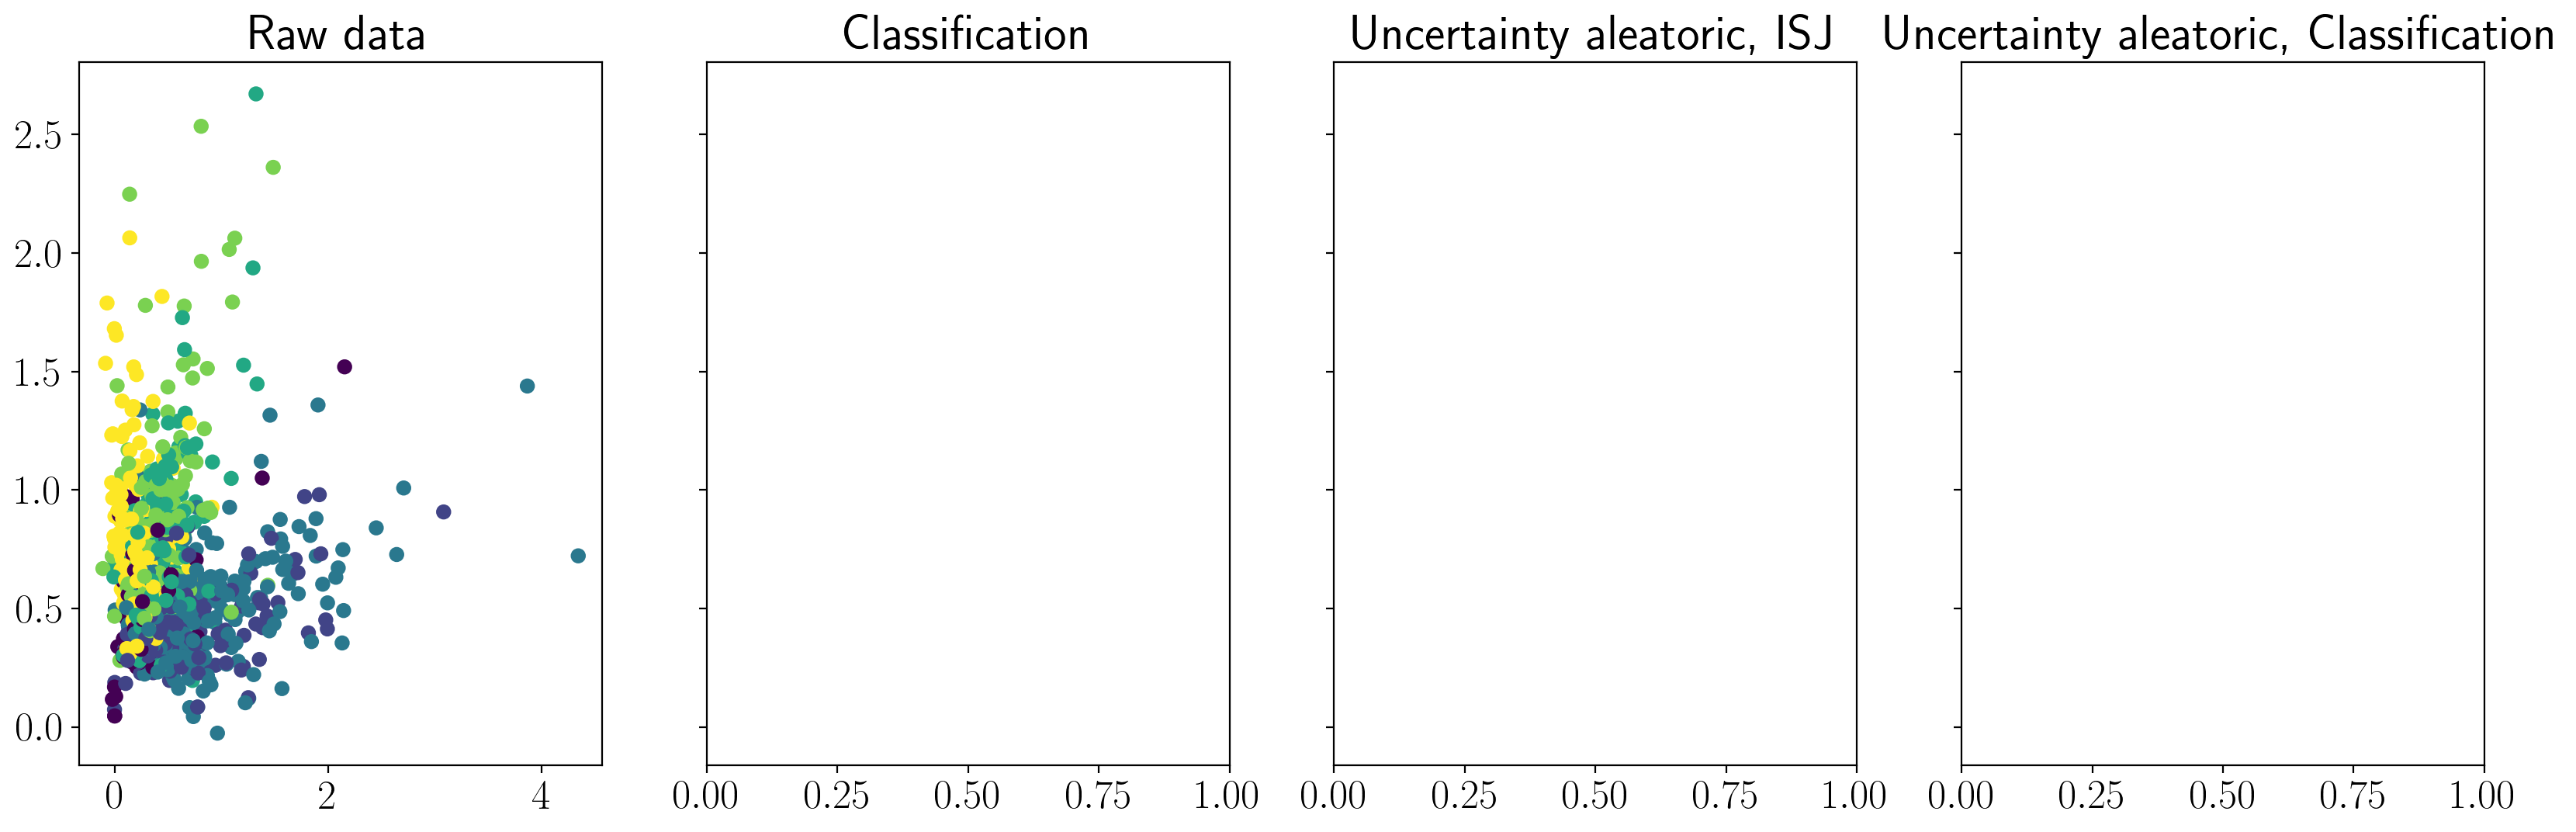

In [15]:
X = first_layer_out.data.numpy()
y = labels.numpy()

#X, y = make_data(total_size=10000,
#                     centers=np.array([[3., 0.], [3., 10.], [0., 10]]))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)
plot_data(X, y)
# strategy options: 'isj', 'silverman', 'scott', 'classification'
# strategy = "classification"
# nw_classifier = NewNW(bandwidth=np.array([1., 1.]), strategy=strategy.lower(), tune_bandwidth=False,
#                       precise_computation=False, n_neighbors=50, use_centroids=False)
# nw_classifier.fit(X=X_train, y=y_train)
#
#x_min, x_max = X[:, 0].min() - 5, X[:, 0].max() + 5
#y_min, y_max = X[:, 1].min() - 5, X[:, 1].max() + 5

#xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
#                        np.arange(y_min, y_max, 0.05))

#X_test = np.c_[xx.ravel(), yy.ravel()]

def misclassfication_detection(y_val, probabilities, uncertainties, estimators):
    results = []
    predictions = np.argmax(probabilities, axis=-1)
    #print("len pred: ", len(predictions))
    #print("len y: ", len(y_val))
    errors = (predictions != y_val)
    for estimator_name in estimators:
        #with np.printoptions(threshold=np.inf):
        #    print("Errors: ", errors)
        #print("Uncert: ", uncertainties[estimator_name])
        fpr, tpr, _ = roc_curve(errors, uncertainties[estimator_name])
        roc_auc = roc_auc_score(errors, uncertainties[estimator_name])
        results.append((estimator_name, roc_auc))

    return results


#print(X_test.shape)
#
#f_hat_y_x = nw_classifier.predict_proba(X_test)["probs"]

#plt.figure(figsize=(10, 7), dpi=200)
#plt.title('Nadaraya-Watson classification')
#plt.contourf(xx, yy, np.max(f_hat_y_x, axis=-1).reshape(*xx.shape))
#plt.show()
#
#Ue = nw_classifier.predict_uncertartainty(X_test)
#plt.figure(figsize=(10, 7), dpi=200)
#plt.title('Nadaraya-Watson Uncertainties')
#plt.contourf(xx, yy, Ue.reshape(*xx.shape))
#plt.show()

fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(20, 6), dpi=200, sharey=True)
# plt.suptitle(f"{strategy} strategy for bandwidth selection")
ax[0].set_title('Raw data')
ax[0].scatter(X_train[:, 0], X_train[:, 1], c=y_train)

# strategy options: 'isj', 'silverman', 'scott', 'classification'
uncertainty_type = "aleatoric"
for i, strategy in enumerate(['ISJ', 'Classification']):
    # strategy = "classification"
    precise_computation = True
    nw_classifier = NewNW(bandwidth=np.array([0.4, 0.4]), strategy=strategy.lower(), tune_bandwidth=True,
                              precise_computation=precise_computation, n_neighbors=100, coeff=1e-10)
    nw_classifier.fit(X=X_train, y=y_train)

    ax[1].set_title('Classification')

    f_hat_y_x = nw_classifier.predict_proba(X_test)["probs"]
    #ax[1].contourf(xx, yy, np.max(f_hat_y_x, axis=-1).reshape(*xx.shape))

    ax[i + 2].set_title(f'Uncertainty {uncertainty_type}, {strategy}')
    uncertainty = nw_classifier.predict_uncertartainty(X_test)
    Ue = uncertainty[uncertainty_type]
    #if precise_computation:
    #    ax[i + 2].contourf(xx, yy, Ue.reshape(*xx.shape))
    #else:
    #    ax[i + 2].contourf(xx, yy, np.log(Ue.reshape(*xx.shape)))
    print("ROC AUC :", misclassfication_detection(y_test, f_hat_y_x, {'test': Ue}, ['test']))
    print(
        f"{strategy}, {[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]}: \n "
        f" {nw_classifier.predict_uncertartainty(np.array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]]))}, \n "
        f"{[10., 0., 10., 0., 10., 0., 10., 0., 10., 0., 10., 0., 10., 0., 10., 0.]}: \n "
        f" {nw_classifier.predict_uncertartainty(np.array([[10., 0., 10., 0., 10., 0., 10., 0., 10., 0., 10., 0., 10., 0., 10., 0.]]))}, \n"
        f"{[20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20.]}: \n "
        f" {nw_classifier.predict_uncertartainty(np.array([[20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20.]]))}"
    )
    
    
#plt.tight_layout()
#with np.printoptions(threshold=np.inf):
    #    print("Uncertainty: ", Ue)
print("Uncertainty : ", Ue)
print("Uncertainty mean: ", np.mean(Ue))
print("Uncertainty max: ", np.amax(Ue))
plt.savefig('./pics/nw_res_log.pdf', format='pdf')
plt.show()